In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json

In [3]:

def calculate_normalized_score(hit_score, max_hit_score):
    """Normalize the hit score using s_norm = s / s_max"""
    return hit_score / max_hit_score if max_hit_score > 0 else 0

def calculate_description_score(issue, weights):
    """Calculate the description score for an issue"""
    exe_d = issue["exe"]
    ext_d = issue["ext"]
    prop_d = issue["prop"]
    
    description_score = (weights["w_exe_d"] * exe_d) + (weights["w_ext_d"] * ext_d) + (weights["w_prop_d"] * prop_d)
    
    return weights["w_description"] * description_score

def calculate_comments_score(comments, weights):
    """Calculate the comments score using the average confidences"""
    if len(comments) == 0:
        return 0

    exe_C = sum([comment["exe_conf"] for comment in comments]) / len(comments)
    ext_C = sum([comment["ext_conf"] for comment in comments]) / len(comments)
    prop_C = sum([comment["prop_conf"] for comment in comments]) / len(comments)
    
    comments_score = (weights["w_exe_c"] * exe_C) +                      (weights["w_ext_c"] * ext_C) +                      (weights["w_prop_c"] * prop_C)
    
    return weights["w_comments"] * comments_score

def calculate_new_score(issue, comments, max_hit_score, weights):
    """Calculate the new score for an issue"""
    # Step 1: Normalize the hit score
    s_norm = calculate_normalized_score(issue["s_norm"], max_hit_score)
    
    # Step 2: Calculate the description score
    description_score = calculate_description_score(issue, weights)
    
    # Step 3: Calculate the comments score
    comments_score = calculate_comments_score(comments, weights)
    
    # Step 4: Combine to form the final score
    new_score = (weights["w_s"] * s_norm) + description_score + comments_score
    
    return new_score

def rank_issues(issues, comments, weights):
    """Rank issues based on the calculated new score"""
    # Find the maximum hit score to normalize
    max_hit_score = max(issue["s_norm"] for issue in issues)

    # Create a list of issues with their calculated scores
    ranked_issues = []
    for issue in issues:
        # Get the relevant comments for the issue
        issue_comments = [comment for comment in comments if comment["issue_id"] == issue["issue_id"]]
        
        # Calculate the new score for the issue
        new_score = calculate_new_score(issue, issue_comments, max_hit_score, weights)
        
        # Append the issue with its calculated score
        ranked_issues.append({
            "issue_id": issue["issue_id"],
            "new_score": new_score,
            "description": issue["description"]
        })

    # Sort issues by the new score in descending order
    ranked_issues.sort(key=lambda x: x["new_score"], reverse=True)
    
    return ranked_issues


In [4]:
## for making ideal solution wr exec:

# Weights as defined in the problem
weights = {
    "w_s": 0.2,
    "w_description": 0.5,
    "w_comments": 0.3,
    "w_exe_d": 0.4,
    "w_ext_d": 0.3,
    "w_prop_d": 0.3,
    "w_exe_c": 0.2,
    "w_ext_c": 0.4,
    "w_prop_c": 0.4
}


# Load the JSON data from the file
with open('selected_issues.json', 'r') as file:
    data = json.load(file)

issues = data["issues"]
comments = data["comments"]


In [5]:


ranked_issues = rank_issues(issues, comments, weights)

# Display the ranked issues
print("Ranked Issues (by new_score):")
for rank, issue in enumerate(ranked_issues, start=1):
    print(f"Rank {rank}: Issue ID {issue['issue_id']} with score {issue['new_score']:.4f} - {issue['description']}")


Ranked Issues (by new_score):
Rank 1: Issue ID 17 with score 0.9200 - High hit score, high confidence across the board.
Rank 2: Issue ID 3 with score 0.8400 - High hit score, high confidence in all categories.
Rank 3: Issue ID 14 with score 0.7740 - High hit score, balanced confidences.
Rank 4: Issue ID 11 with score 0.7438 - High hit score, strong in executive and existence.
Rank 5: Issue ID 7 with score 0.5844 - Low hit score, high confidence in executive and property.
Rank 6: Issue ID 9 with score 0.5738 - High hit score, low confidence in executive and property.
Rank 7: Issue ID 16 with score 0.5129 - Low hit score, high executive confidence.
Rank 8: Issue ID 5 with score 0.4597 - Low hit score, average confidence but low existence.
Rank 9: Issue ID 1 with score 0.3477 - Low hit score, low confidence in all categories.
Rank 10: Issue ID 19 with score 0.2454 - Low hit score, low confidence across the board.


In [6]:
## for making ideal solution wr exe:

# Weights as defined in the problem
weights = {
    "w_s": 0.2,
    "w_description": 0.5,
    "w_comments": 0.3,
    "w_exe_d": 0.8,
    "w_ext_d": 0.1,
    "w_prop_d": 0.1,
    "w_exe_c": 0.7,
    "w_ext_c": 0.3,
    "w_prop_c": 0.0
}


# Load the JSON data from the file
with open('selected_issues.json', 'r') as file:
    data = json.load(file)

# Create an array with issue_id, score, confidences, total comments, avg confidences from comments
result = []

for issue in data["issues"]:
    issue_id = issue["issue_id"]
    score = issue["s_norm"]
    exe_conf = issue["exe"]
    prop_conf = issue["prop"]
    ext_conf = issue["ext"]
    
    # Find all comments for this issue
    issue_comments = [comment for comment in data["comments"] if comment["issue_id"] == issue_id]
    total_comments = len(issue_comments)
    
    # Calculate average confidences from comments
    if total_comments > 0:
        avg_exe_conf = np.mean([comment["exe_conf"] for comment in issue_comments])
        avg_prop_conf = np.mean([comment["prop_conf"] for comment in issue_comments])
        avg_ext_conf = np.mean([comment["ext_conf"] for comment in issue_comments])
    else:
        avg_exe_conf = avg_prop_conf = avg_ext_conf = 0
    
    # Append the result
    result.append({
        "issue_id": issue_id,
        "score": score,
        "exe_conf": exe_conf,
        "prop_conf": prop_conf,
        "ext_conf": ext_conf,
        "total_comments": total_comments,
        "avg_exe_conf": avg_exe_conf,
        "avg_prop_conf": avg_prop_conf,
        "avg_ext_conf": avg_ext_conf,
        "description": issue["description"],
        # "comment_description": issue[""]
    })

issues = result

def calculate_new_score(w_s, s_norm, n, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop):
    # Calculate the first part of the formula
    first_part = w_s * s_norm

    # Calculate the second part of the formula
    second_part = (np.log(n+1) /(np.log(4)+np.log(n+1)))* ((w_exec_c * exe_C + w_ext_c * ext_C + w_prop_c * prop_C))

    # Calculate the third part of the formula
    third_part = (np.log(4)/(np.log(4)+np.log(n +1))) *((w_exec_d * exe + w_ext_d * ext + w_prop_d * prop))

    # Combine all parts to get the final score
    new_score = first_part + second_part + third_part

    return new_score

# Rank the issues based on the provided formula
print("unranked Issueds")
issues.sort(key=lambda x: x["score"], reverse=True)
for rank, issue in enumerate(issues, start=1):
    print(f"Rank {rank}: Issue ID {issue['issue_id']}  - issues ({issue['exe_conf']}, {issue['ext_conf']}, {issue['prop_conf']}) - {issue['total_comments']} comments with avg({issue['avg_exe_conf']}, {issue['avg_ext_conf']}, {issue['avg_prop_conf']})                  -with score {issue['score']:.4f}")

print(issues)

ranked_issues = []
for issue in issues:
    # "w_exe_d": 0.4,
    # "w_ext_d": 0.3,
    # "w_prop_d": 0.3,
    # "w_exe_c": 0.2,
    # "w_ext_c": 0.4,
    # "w_prop_c": 0.4
    
    # Calculate the new score for the issue
    new_score = calculate_new_score(weights["w_s"],issue["score"],issue["total_comments"],weights["w_exe_c"],issue["avg_exe_conf"], weights["w_ext_c"], issue["avg_ext_conf"],weights['w_prop_c'], issue['avg_prop_conf'], weights['w_exe_d'],issue["exe_conf"], weights['w_ext_d'],issue['ext_conf'], weights['w_prop_d'], issue['prop_conf'])
    
    # Append the issue with its calculated score
    ranked_issues.append({
        "issue_id": issue["issue_id"],
        "new_score": new_score,
        "description": issue["description"]
    })

# Sort issues by the new score in descending order
ranked_issues.sort(key=lambda x: x["new_score"], reverse=True)
    
# Display the ranked issues
print("Ranked Issues (by new_score):")
for rank, issue in enumerate(ranked_issues, start=1):
    print(f"Rank {rank}: Issue ID {issue['issue_id']} with score {issue['new_score']:.4f} - {issue['description']}")
    
    
    
expected_issues_for_exec = [3, 17, 7, 11, 16, 5, 14, 1, 9, 19]

expected_issues_for_prop = []


unranked Issueds
Rank 1: Issue ID 3  - issues (0.8, 0.9, 0.7) - 5 comments with avg(0.8, 0.8, 0.8)                  -with score 0.9000
Rank 2: Issue ID 14  - issues (0.5, 0.9, 0.7) - 5 comments with avg(0.5, 0.9, 0.8)                  -with score 0.9000
Rank 3: Issue ID 17  - issues (0.9, 0.9, 0.9) - 3 comments with avg(0.9, 0.9, 0.9)                  -with score 0.9000
Rank 4: Issue ID 9  - issues (0.3, 0.8, 0.4) - 2 comments with avg(0.4, 0.8, 0.3)                  -with score 0.8000
Rank 5: Issue ID 11  - issues (0.7, 0.8, 0.6) - 5 comments with avg(0.8, 0.8, 0.6)                  -with score 0.8000
Rank 6: Issue ID 16  - issues (0.8, 0.4, 0.4) - 2 comments with avg(0.8, 0.4, 0.4)                  -with score 0.4000
Rank 7: Issue ID 1  - issues (0.4, 0.4, 0.3) - 1 comments with avg(0.4, 0.3, 0.3)                  -with score 0.3000
Rank 8: Issue ID 5  - issues (0.6, 0.3, 0.6) - 2 comments with avg(0.6, 0.4, 0.45)                  -with score 0.3000
Rank 9: Issue ID 7  - issues (0.9,

In [7]:
## for making ideal solution wr prop:

# Weights as defined in the problem
weights = {
    "w_s": 0.2,
    "w_description": 0.5,
    "w_comments": 0.3,
    "w_exe_d": 0.1,
    "w_ext_d": 0.1,
    "w_prop_d": 0.8,
    "w_exe_c": 0.0,
    "w_ext_c": 0.8,
    "w_prop_c": 0.2
}


# Load the JSON data from the file
with open('selected_issues.json', 'r') as file:
    data = json.load(file)

# Create an array with issue_id, score, confidences, total comments, avg confidences from comments
result = []

for issue in data["issues"]:
    issue_id = issue["issue_id"]
    score = issue["s_norm"]
    exe_conf = issue["exe"]
    prop_conf = issue["prop"]
    ext_conf = issue["ext"]
    
    # Find all comments for this issue
    issue_comments = [comment for comment in data["comments"] if comment["issue_id"] == issue_id]
    total_comments = len(issue_comments)
    
    # Calculate average confidences from comments
    if total_comments > 0:
        avg_exe_conf = np.mean([comment["exe_conf"] for comment in issue_comments])
        avg_prop_conf = np.mean([comment["prop_conf"] for comment in issue_comments])
        avg_ext_conf = np.mean([comment["ext_conf"] for comment in issue_comments])
    else:
        avg_exe_conf = avg_prop_conf = avg_ext_conf = 0
    
    # Append the result
    result.append({
        "issue_id": issue_id,
        "score": score,
        "exe_conf": exe_conf,
        "prop_conf": prop_conf,
        "ext_conf": ext_conf,
        "total_comments": total_comments,
        "avg_exe_conf": avg_exe_conf,
        "avg_prop_conf": avg_prop_conf,
        "avg_ext_conf": avg_ext_conf,
        "description": issue["description"],
        # "comment_description": issue[""]
    })

issues = result

def calculate_new_score(w_s, s_norm, n, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop):
    # Calculate the first part of the formula
    first_part = w_s * s_norm
    # first_part =0

    # Calculate the second part of the formula
    second_part = (np.log(n+1) /(np.log(4)+np.log(n+1)))* ((w_exec_c * exe_C + w_ext_c * ext_C + w_prop_c * prop_C))

    # Calculate the third part of the formula
    third_part = (np.log(4)/(np.log(4)+np.log(n +1))) *((w_exec_d * exe + w_ext_d * ext + w_prop_d * prop))

    # Combine all parts to get the final score
    new_score = first_part + second_part + third_part

    return new_score

# Rank the issues based on the provided formula
print("unranked Issueds")
issues.sort(key=lambda x: x["prop_conf"], reverse=True)
for rank, issue in enumerate(issues, start=1):
    print(f"Rank {rank}: Issue ID {issue['issue_id']}  - issues ({issue['exe_conf']}, {issue['ext_conf']}, {issue['prop_conf']}) - {issue['total_comments']} comments with avg({issue['avg_exe_conf']}, {issue['avg_ext_conf']}, {issue['avg_prop_conf']})                  -with score {issue['score']:.4f}")

print(issues)

ranked_issues = []
for issue in issues:
    
    # Calculate the new score for the issue
    new_score = calculate_new_score(weights["w_s"],issue["score"],issue["total_comments"],weights["w_exe_c"],issue["avg_exe_conf"], weights["w_ext_c"], issue["avg_ext_conf"],weights['w_prop_c'], issue['avg_prop_conf'], weights['w_exe_d'],issue["exe_conf"], weights['w_ext_d'],issue['ext_conf'], weights['w_prop_d'], issue['prop_conf'])
    
    # Append the issue with its calculated score
    ranked_issues.append({
        "issue_id": issue["issue_id"],
        "new_score": new_score,
        "description": issue["description"]
    })

# Sort issues by the new score in descending order
ranked_issues.sort(key=lambda x: x["new_score"], reverse=True)
    
# Display the ranked issues
print("Ranked Issues (by new_score):")
for rank, issue in enumerate(ranked_issues, start=1):
    print(f"Rank {rank}: Issue ID {issue['issue_id']} with score {issue['new_score']:.4f} - {issue['description']}")
    
    

expected_issues_for_prop = [17, 14, 3, 7, 11, 5 ,9, 16, 1, 19]


unranked Issueds
Rank 1: Issue ID 17  - issues (0.9, 0.9, 0.9) - 3 comments with avg(0.9, 0.9, 0.9)                  -with score 0.9000
Rank 2: Issue ID 7  - issues (0.9, 0.2, 0.8) - 3 comments with avg(0.9, 0.4000000000000001, 0.9)                  -with score 0.2000
Rank 3: Issue ID 3  - issues (0.8, 0.9, 0.7) - 5 comments with avg(0.8, 0.8, 0.8)                  -with score 0.9000
Rank 4: Issue ID 14  - issues (0.5, 0.9, 0.7) - 5 comments with avg(0.5, 0.9, 0.8)                  -with score 0.9000
Rank 5: Issue ID 5  - issues (0.6, 0.3, 0.6) - 2 comments with avg(0.6, 0.4, 0.45)                  -with score 0.3000
Rank 6: Issue ID 11  - issues (0.7, 0.8, 0.6) - 5 comments with avg(0.8, 0.8, 0.6)                  -with score 0.8000
Rank 7: Issue ID 9  - issues (0.3, 0.8, 0.4) - 2 comments with avg(0.4, 0.8, 0.3)                  -with score 0.8000
Rank 8: Issue ID 16  - issues (0.8, 0.4, 0.4) - 2 comments with avg(0.8, 0.4, 0.4)                  -with score 0.4000
Rank 9: Issue ID 1 

In [8]:
def calculate_new_score(w_s, s_norm, n, n_max, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop):
    # Calculate the first part of the formula
    first_part = w_s * s_norm

    # Calculate the second part of the formula
    second_part = (n + n_max / n) * (w_exec_c * exe_C + w_ext_c * ext_C + w_prop_c * prop_C)

    # Calculate the third part of the formula
    third_part = (n_max / n_max - n) * (w_exec_d * exe + w_ext_d * ext + w_prop_d * prop)

    # Combine all parts to get the final score
    new_score = first_part + second_part + third_part

    return new_score

# Example usage
w_s = 0.5
s_norm = 10
n = 2
n_max = 5
w_exec_c = 0.2
exe_C = 1
w_ext_c = 0.3
ext_C = 2
w_prop_c = 0.4
prop_C = 3
w_exec_d = 0.25
exe = 4
w_ext_d = 0.35
ext = 5
w_prop_d = 0.45
prop = 6

score = calculate_new_score(w_s, s_norm, n, n_max, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop)
print("The new score is:", score)


The new score is: 8.55


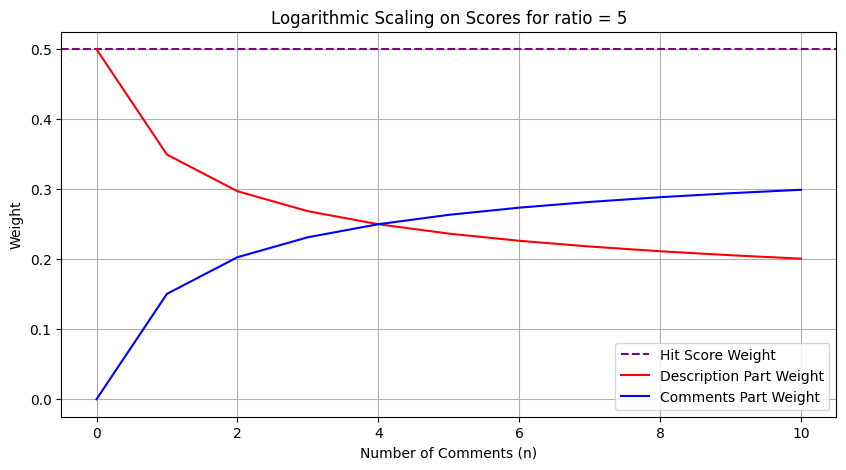

In [25]:


def calculate_first_part(w_s, s_norm):
    return w_s * s_norm

# def calculate_second_part(n, n_max, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C):
#     return (2/ (n +2))  #* (w_exec_c * exe_C + w_ext_c * ext_C + w_prop_c * prop_C)

# def calculate_third_part(n, n_max, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop):
#     return (n / (n+2)) #* (w_exec_d * exe + w_ext_d * ext + w_prop_d * prop)


def calculate_second_part(n, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C):
    # Using logarithms for normalization
    return (.5)*(np.log(n+1) /(np.log(5)+np.log(n+1)))* ((w_exec_c * exe_C + w_ext_c * ext_C + w_prop_c * prop_C))

def calculate_third_part(n, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop):
    # Using logarithms for normalization
    return  (.5)*(np.log(5)/(np.log(5 )+np.log(n +1))) *((w_exec_d * exe + w_ext_d * ext + w_prop_d * prop))

# def calculate_second_part(n, n_max, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C):
#     # Using logarithms for normalization
#     return (np.log(n+1) /(np.log(4)+np.log(n+1)))

# def calculate_third_part(n, n_max, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop):
#     # Using logarithms for normalization
#     return  (np.log(4)/(np.log(4)+np.log(n +1))) 


# Parameters

# first part
w_s = 0.5   # Weight for Apache Lucene Score
s_norm = 1 # Normalized Apache Lucene Score

# dynamic parameters
ratio = 5 # comments to description ratio
# n = 5 # number of comments per issue

# second part
w_exec_d = 0.5 # Weight for Execution Confidence in Description
w_ext_d = 0.3 # Weight for Existence Confidence in Description
w_prop_d = 0.2  # Weight for Propagation Confidence in Description

exe = 1   # Execution Confidence in Description
ext = 1   # Existence Confidence in Description
prop = 1  # Propagation Confidence in Description

# third part
w_exec_c = 0.5 # Weight for Execution Confidence in Comments 
w_ext_c = 0.3  # Weight for Existence Confidence in Comments
w_prop_c = 0.2 # Weight for Propagation Confidence in Comments

exe_C = 1 # Average Execution Confidence in Comments
ext_C = 1 # Average Existence Confidence in Comments
prop_C = 1 # Average Propagation Confidence in Comments


# Generate values for n
n_values = [0,1,2,3,4,5,6,7,8,9,10]#,11,12,13,14,15,16,17,18,19]
second_part_values = [calculate_second_part(n, w_exec_c, exe_C, w_ext_c, ext_C, w_prop_c, prop_C) for n in n_values]
third_part_values = [calculate_third_part(n, w_exec_d, exe, w_ext_d, ext, w_prop_d, prop) for n in n_values]

# problem normalization of the weights that we got

# Calculate components of the second part
components_exec_c = [w_exec_c * exe_C for _ in n_values]
components_ext_c = [w_ext_c * ext_C for _ in n_values]
components_prop_c = [w_prop_c * prop_C for _ in n_values]

# Calculate the first part value (constant for given w_s and s_norm)
first_part_value = calculate_first_part(w_s, s_norm)

# Plotting
plt.figure(figsize=(10, 5))

plt.axhline(y=first_part_value, color='purple', linestyle='--', label='Hit Score Weight')
plt.plot(n_values, third_part_values, label='Description Part Weight', color='red')

plt.plot(n_values, second_part_values, label='Comments Part Weight', color='blue')

plt.xlabel('Number of Comments (n)')
plt.ylabel('Weight')
plt.title('Logarithmic Scaling on Scores for ratio = 5') 
plt.legend()
plt.grid(True)
plt.savefig(f"Logarithmic Scaling.pdf", dpi=300, bbox_inches='tight')

plt.show()
